# MVP Machine Learning & Analytics

**Nome:** Matheus Henrique Santos da Silva

**Matrícula:** 4052025001423

Dataset: Online-Learning-Engagement-Dataset



# Descrição do Problema

Conjunto de Dados de Engajamento em Aprendizagem Online

Este conjunto de dados contém dados sintéticos que representam o engajamento e o comportamento de aprendizagem dos alunos em um ambiente de educação online. Inclui diversas características relacionadas a dados demográficos dos alunos, hábitos de estudo, atividade na plataforma e desempenho acadêmico.

O conjunto de dados foi projetado para simular cenários realistas de aprendizagem online e pode ser usado para mineração de dados educacionais, experimentos de aprendizado de máquina e projetos de análise.

As principais variáveis ​​incluem frequência de login dos alunos, horas de estudo, tempo de visualização de vídeos, envio de tarefas, tentativas de questionários e métricas de engajamento. Essas características ajudam a capturar como os alunos interagem com as plataformas de aprendizagem digital.




## Objetivo
Este dataset será utilizado com o objetivo Prever a nota final dos alunos a partir do conjunto de informações a respeito de seus hábitos de estudo. Será utilizado um modelo de regressão linear múltipla como baseline e o challenger será um modelo xgoboost regressor

## Hipóteses

**Hipótese 1**

A relação entre as variáveis explicativas e a nota final é predominantemente linear.

**Hipótese 2**

Grande parte da informação está concentrada nas variaveis de engajamento do aluno em atividades.

**Hipótese 3**

Não existem interações complexas no dataset.

## Tipo de Problema

Este é um problema de **regressão supervisionada**. Dado um conjunto de características (idade, sexo, numero de horas em estudo na semana), pode-se criar um modelo de regressão para prever as notas dos alunos.

## Seleção de Dados

Plataformas de educação online geram grandes quantidades de dados comportamentais. Compreender os padrões de engajamento dos alunos pode ajudar os educadores a aprimorar as experiências de aprendizagem e identificar alunos que podem estar em risco de evasão escolar. A base esta pronta para uso e foi recolhida no *Kaggle* no link: https://www.kaggle.com/datasets/ssssws/online-learning-engagement-dataset

## Atributos do Dataset

O dataset contém 50 mil linhas, com 18 colunas:

- ***student_id*** (Unique identifier assigned to each student in the dataset.)
- ***age*** (Age of the student participating in the online learning platform.)
- ***gender*** (Gender of the student (e.g., Male, Female).)
- ***country*** (Country where the student is located.)
- ***device_type*** (Type of device used to access the online learning platform (Laptop, Mobile, Tablet).)
- ***internet_speed_mbps*** (Internet connection speed of the student in megabits per second (Mbps).)
- ***study_hours_weekly*** (Average number of hours the student spends studying per week.)
- ***login_frequency_weekly*** (Number of times the student logs into the learning platform each week.)
- ***avg_session_duration_min*** (Average duration of a learning session in minutes.)
- ***video_watch_time_min*** (Total time spent watching course videos in minutes.)
- ***assignments_submitted***
- ***forum_posts***
- ***quiz_attempts***
- ***avg_quiz_score***
- ***attendance_rate***
- ***engagement_score***
- ***final_grade***
- ***dropout***

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset.

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import json
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

In [3]:
# @title
# carregamento do dataset
url = "https://raw.githubusercontent.com/Matheus-hss/Online-Learning-Engagement-Dataset/main/online_learning_engagement_dataset.csv"

df = pd.read_csv(url)

df.head()

,student_id,age,gender,country,device_type,internet_speed_mbps,study_hours_weekly,login_frequency_weekly,avg_session_duration_min,video_watch_time_min,assignments_submitted,forum_posts,quiz_attempts,avg_quiz_score,attendance_rate,engagement_score,final_grade,dropout
0,1,24,Female,USA,Laptop,44.70,15.92,10,40.052752,294.099759,3,4,6,46.69,0.93,8.046499,22.447641,0
1,2,37,Female,Germany,Tablet,61.10,6.37,8,32.442671,400.397658,7,14,5,62.65,0.59,6.312988,39.749905,1
2,3,46,Female,Australia,Tablet,43.10,6.64,7,43.614509,190.239738,1,14,5,58.42,0.43,4.143199,31.061688,1
3,4,32,Male,India,Tablet,26.99,10.91,5,30.697263,370.451629,3,1,2,61.21,0.65,6.125258,41.300634,0
4,5,28,Male,India,Laptop,52.28,7.41,6,47.402999,151.341296,4,4,6,74.92,0.55,4.979706,39.148998,1


# Análise Exploratória de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset, vamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset possui 50 mil observações, com 18 colunas em formatos que variam de interger, float e object.

In [4]:
# @title
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 50000

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                50000 non-null  int64  
 1   age                       50000 non-null  int64  
 2   gender                    50000 non-null  object 
 3   country                   50000 non-null  object 
 4   device_type               50000 non-null  object 
 5   internet_speed_mbps       50000 non-null  float64
 6   study_hours_weekly        50000 non-null  float64
 7   login_frequency_weekly    50000 non-null  int64  
 8   avg_session_duration_min  50000 non-null  float64
 9   video_watch_time_min      50000 non-null  float64
 10  assignments_submitted     50000 non-null  int64  
 11  forum_posts               50000 non-null  int64  
 12  quiz_attempts             50000 non-null  int64  
 13  avg_qu

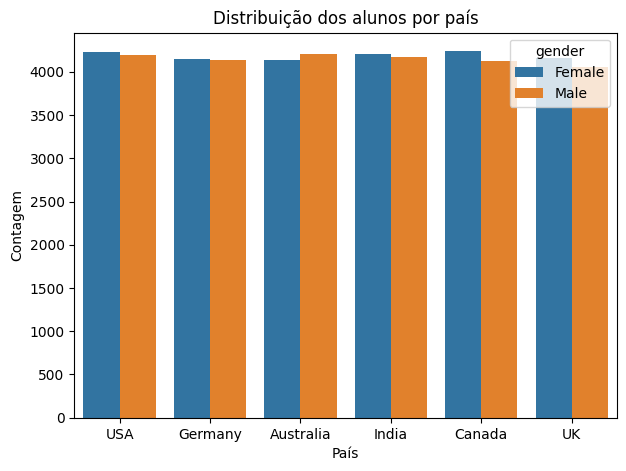

In [5]:
# @title
plt.figure(figsize=(7, 5))
# gráfico de barras simples
sns.countplot(x='country', data=df, hue= 'gender')
plt.title('Distribuição dos alunos por país')
plt.xlabel('País')
plt.ylabel('Contagem')
plt.show()

O gráfico de barras indica uma distribuição equilibrada de alunos por país, mas destaca que os EUA têm a maior concentração, predominando o gênero feminino.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [6]:
# @title
# estatísticas descritivas básicas do dataset apenas das variaveis numéricas excluindo a coluna de id do aluno
df.drop(columns=['student_id']).select_dtypes(include=[np.number]).describe()

,age,internet_speed_mbps,study_hours_weekly,login_frequency_weekly,avg_session_duration_min,video_watch_time_min,assignments_submitted,forum_posts,quiz_attempts,avg_quiz_score,attendance_rate,engagement_score,final_grade,dropout
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,33.539960,49.996111,10.009115,7.498780,40.044473,299.748579,4.486120,6.985980,4.003100,70.018199,0.700335,6.199321,36.854200,0.32412
std,9.188219,14.992648,4.000621,4.026195,14.966684,119.331233,2.872367,4.325459,1.998742,15.057111,0.173304,1.510398,9.012627,0.46805
min,18.000000,-7.300000,-5.790000,1.000000,-19.874917,-237.960893,0.000000,0.000000,1.000000,1.940000,0.400000,-0.353095,-0.173269,0.00000
25%,26.000000,39.920000,7.310000,4.000000,29.986016,219.140815,2.000000,3.000000,2.000000,59.850000,0.550000,5.174603,30.765320,0.00000
50%,34.000000,50.050000,9.995000,8.000000,40.078174,299.620686,4.000000,7.000000,4.000000,70.000000,0.700000,6.200308,36.846286,0.00000
75%,41.000000,60.090000,12.680000,11.000000,50.159928,380.161206,7.000000,11.000000,6.000000,80.130000,0.850000,7.216701,42.936420,1.00000
max,49.000000,111.170000,25.540000,14.000000,108.765278,778.595742,9.000000,14.000000,7.000000,137.490000,1.000000,12.620085,73.717902,1.00000


## Analise inicial

Há valores impossíveis em várias variáveis.

Exemplos:

* internet_speed_mbps: min = -7.3
* study_hours_weekly: min = -5.79
* avg_session_duration_min: min = -19.87
* video_watch_time_min: min = -237.96
* engagement_score: min < 0
* final_grade: min < 0

Isso indica erro de geração de dados ou falta de tratamento de outliers

## Distribuição

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

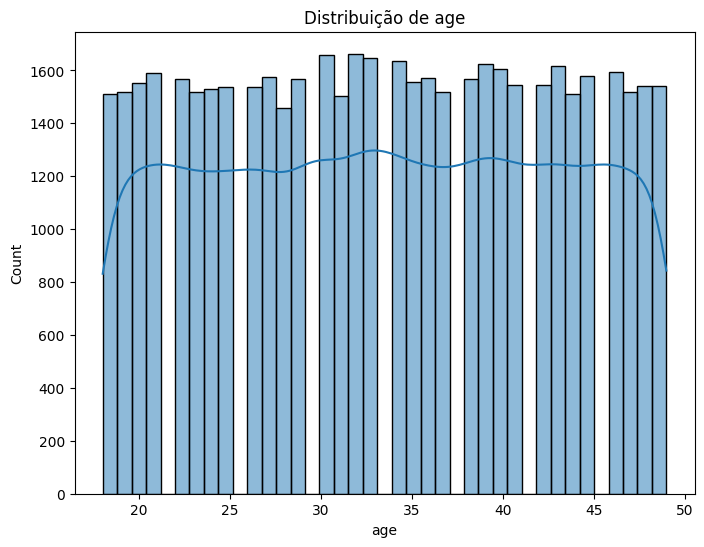

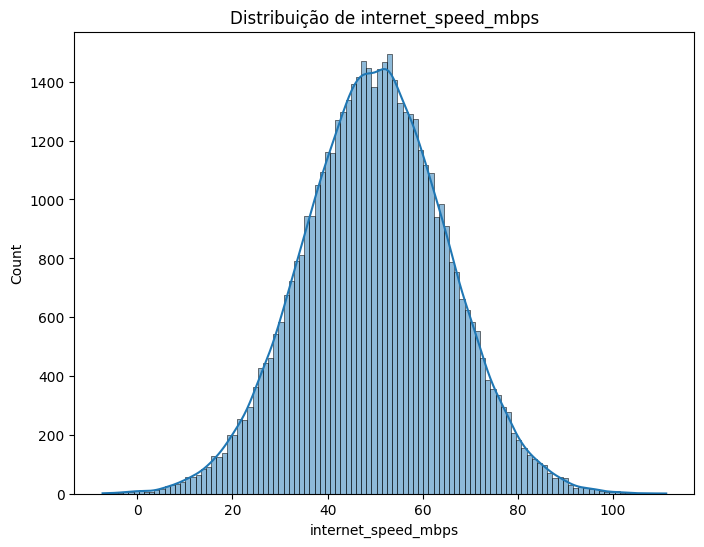

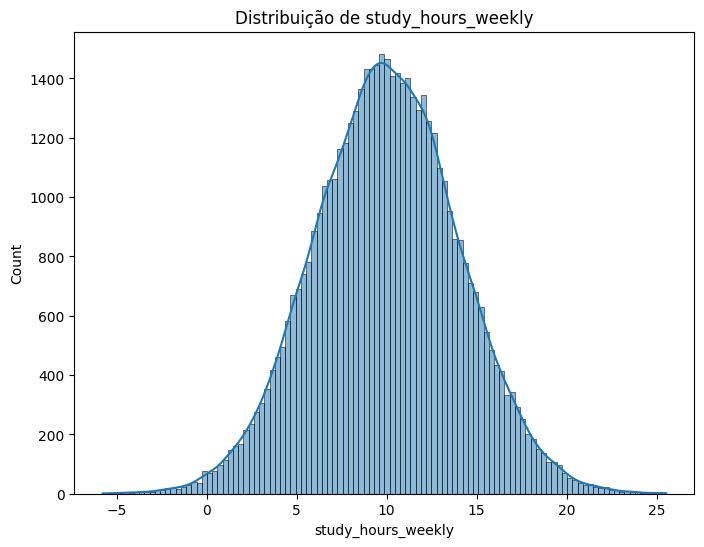

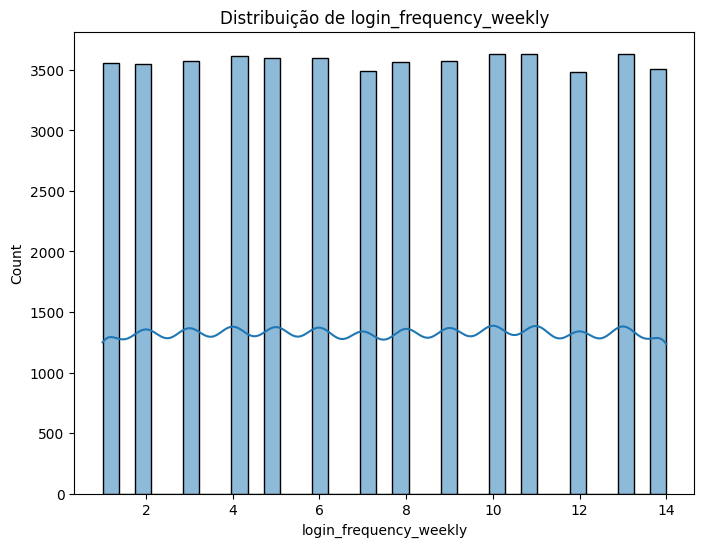

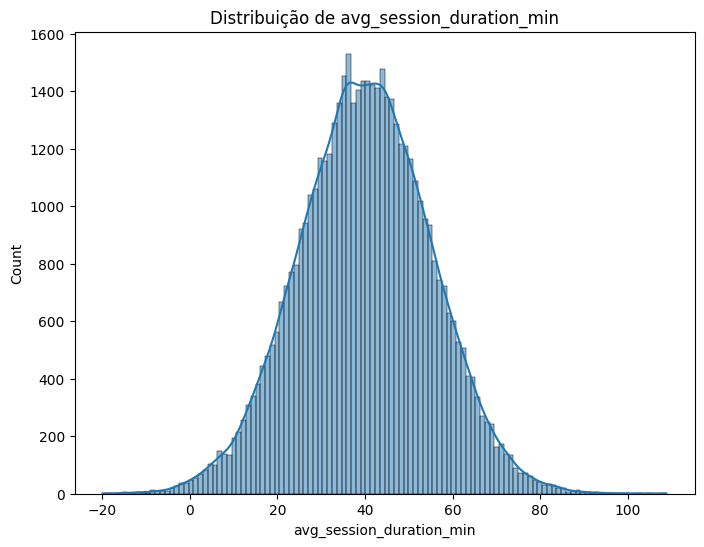

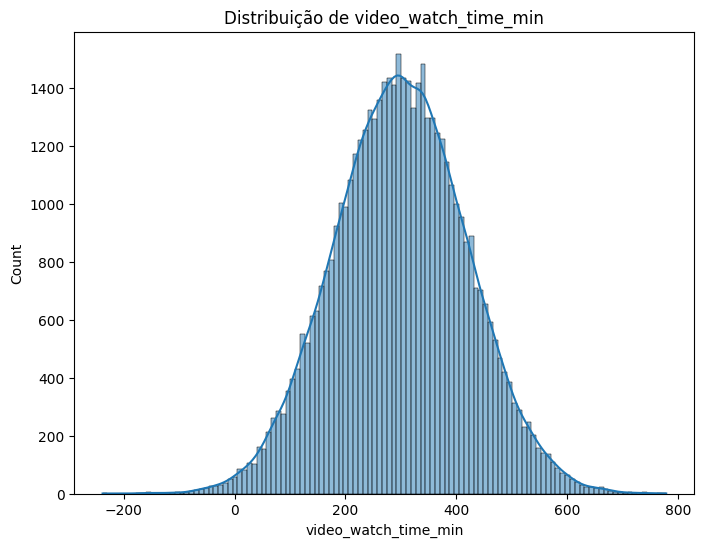

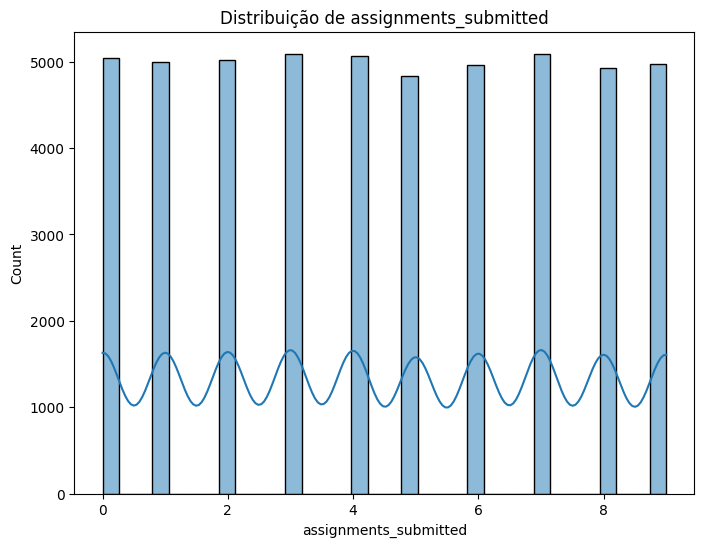

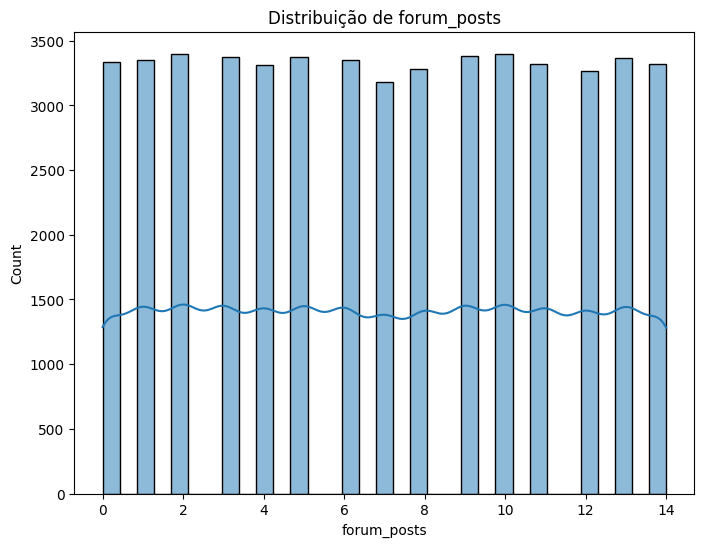

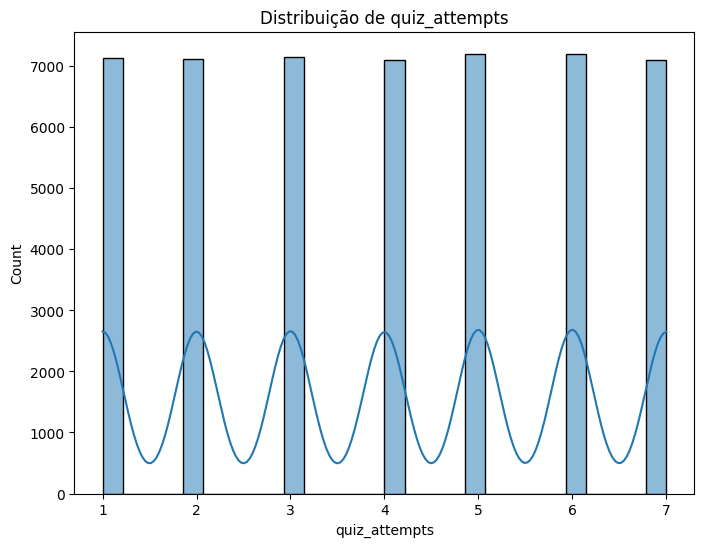

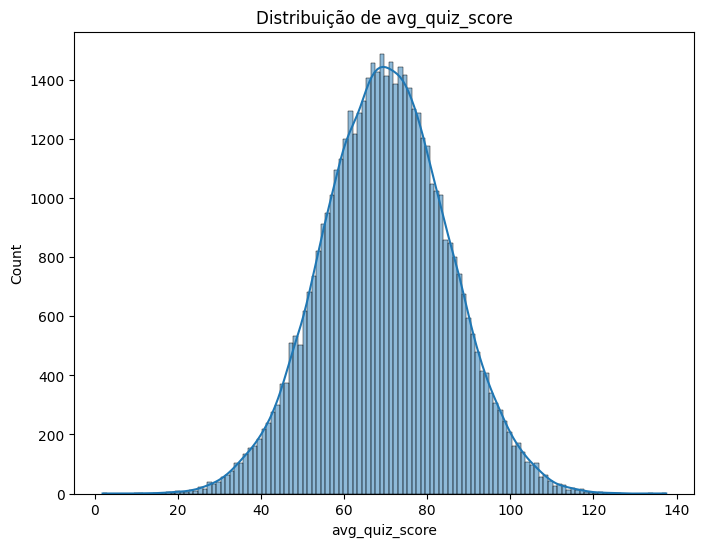

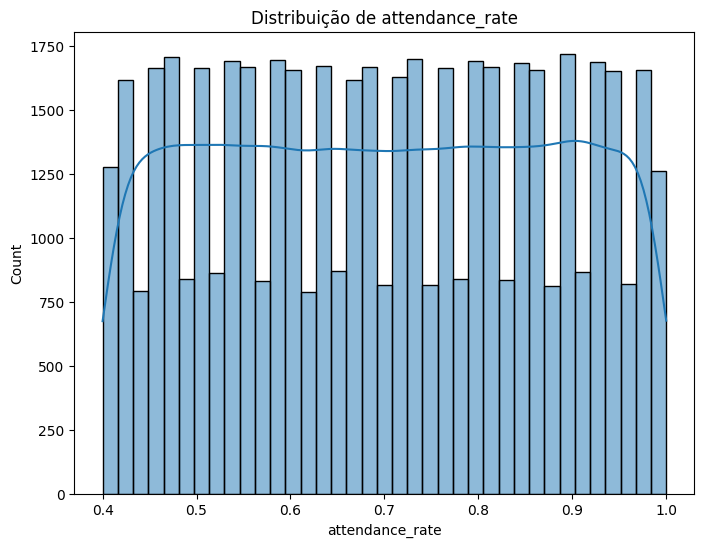

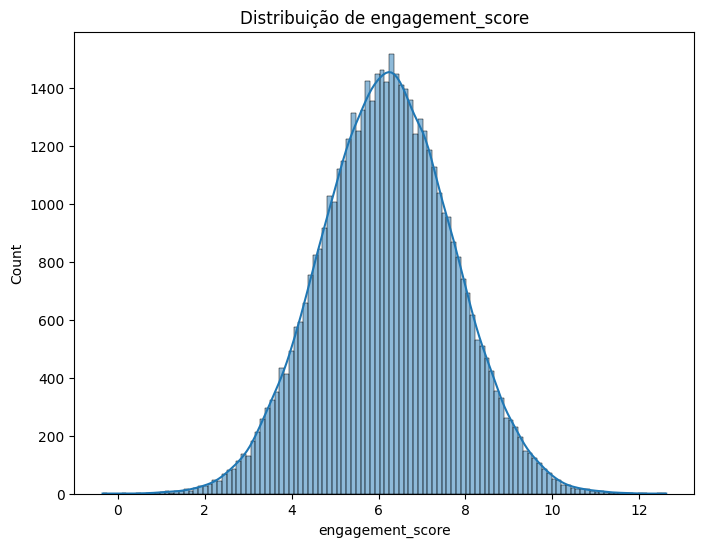

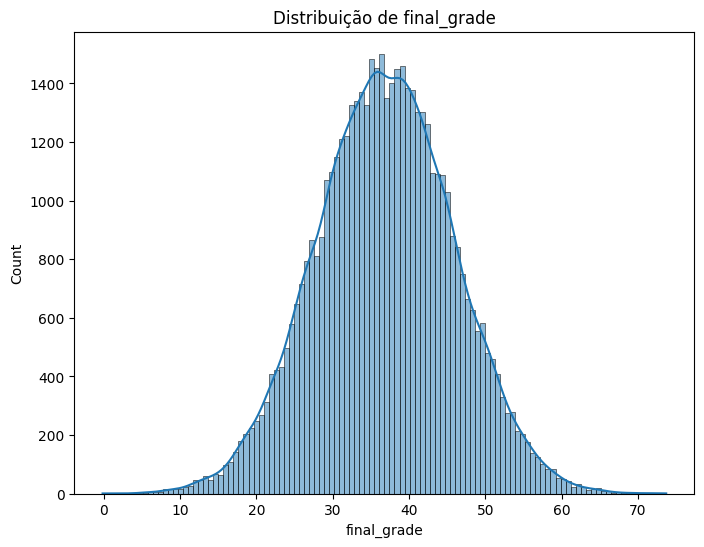

In [7]:
#Função para construir gráfico de distribuição para cada uma das colunas do dataset
lista_colunas = df.drop(columns=['student_id', 'gender', 'country', 'device_type', 'dropout'])

for coluna in lista_colunas:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[coluna], kde=True)
    plt.title(f'Distribuição de {coluna}')
    plt.xlabel(coluna)
    plt.show()


A maior parte das variaveis possui distribuição normal ou unfirme, em seguida vamos analisar com boxplot as possiveis variaveis com outliers

## Padronização e Boxplot

O gráfico boxplot nos permite comparar a média, mediana e desvio padrão de cada uma das variaveis com possiveis outliers indentificadas na analise inicial e saber se o tratamento é necessário.


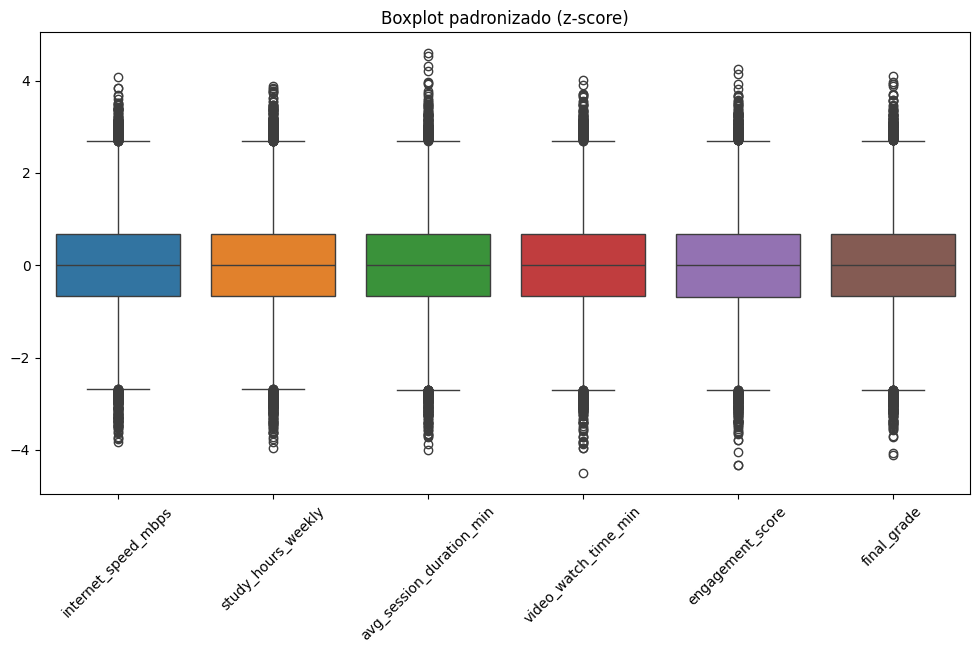

In [8]:
# @title
#Criando uma função para gerar um boxplot para cada uma das seguintes variaveis:
#'internet_speed_mbps',
#'study_hours_weekly',
#'avg_session_duration_min',
#'video_watch_time_min',
#'engagement_score',
#'final_grade'

box_analise = ['internet_speed_mbps',
    'study_hours_weekly',
    'avg_session_duration_min',
    'video_watch_time_min',
    'engagement_score',
    'final_grade']

scaler = StandardScaler() #usamos padronização para facilitar a leitura

df_scaled = pd.DataFrame(
    scaler.fit_transform(df[box_analise]),
    columns=box_analise
)

plt.figure(figsize=(12, 6))

sns.boxplot(data=df_scaled)

plt.title('Boxplot padronizado (z-score)')
plt.xticks(rotation=45)

plt.show()

Outliers — diagnóstico

🔻 Negativos: impossíveis do ponto de vista físico (ex: tempo negativo)

🔺 Positivos: distribuição com caudas mais pesadas que normal ou presença de ruído artificial extremo

Mesmo após padronização os outliers continuam extremos.

Isso indica que não são apenas escala → são valores realmente inconsistentes

video_watch_time_min e avg_session_duration_min
maior dispersão relativa e outliers mais extremos

study_hours_weekly
distribuição bem centrada menos extremos variável mais “estável”

engagement_score presença de valores negativos

final_grade caudas relevantes possível inconsistência de escala

Implicações para modelagem Sem tratamento → risco alto de:
* distorção de coeficientes (logit/OLS)
* splits ruins (árvores)
* overfitting em outliers

## Tratamento de Outliers

In [9]:
#removendo valores impossiveis, exemplo 'study_hours_weekly < 0'

df[box_analise] = df[box_analise].clip(lower=0)

In [10]:
#Tratar outliers extremos com winsorização

def winsorize(series, lower=0.01, upper=0.99):
    # series here is expected to be a pandas Series (single column)
    return series.clip(
        lower=series.quantile(lower),
        upper=series.quantile(upper)
    )

for col in box_analise:
    # Apply winsorize to each column individually
    df[col] = winsorize(df[col])

Rodar novamente o código do boxplot para verificar:

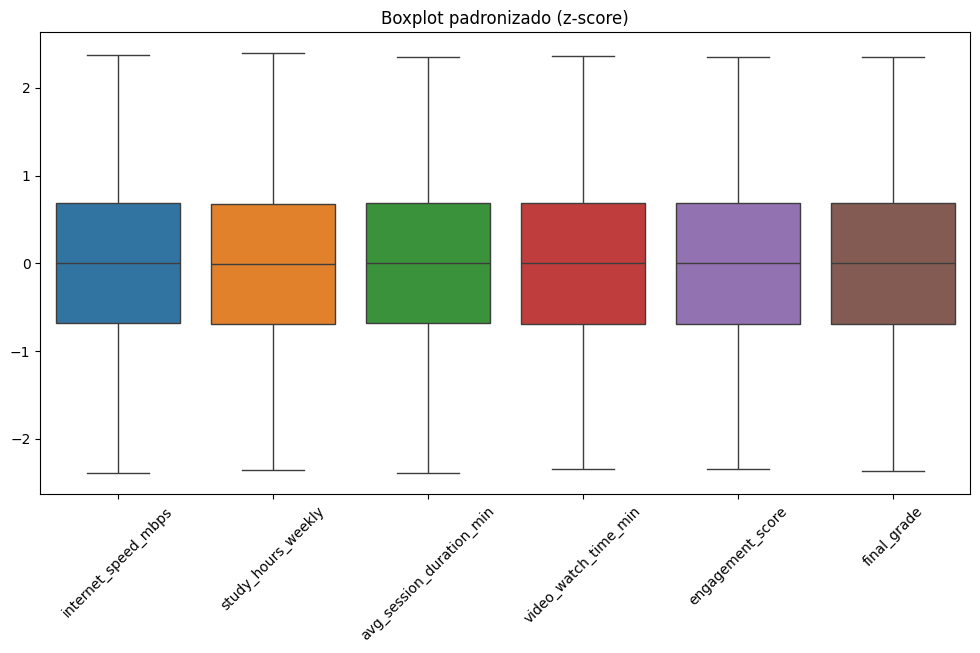

In [11]:
box_analise = ['internet_speed_mbps',
    'study_hours_weekly',
    'avg_session_duration_min',
    'video_watch_time_min',
    'engagement_score',
    'final_grade']

scaler = StandardScaler() #usamos padronização para facilitar a leitura

df_scaled = pd.DataFrame(
    scaler.fit_transform(df[box_analise]),
    columns=box_analise
)

plt.figure(figsize=(12, 6))

sns.boxplot(data=df_scaled)

plt.title('Boxplot padronizado (z-score)')
plt.xticks(rotation=45)

plt.show()

Outliers ajustados.

## Tratamento de Valores Nulos

O dataset não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [12]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset:")
df.isnull().sum()

Valores nulos no dataset:


,0
student_id,0
age,0
gender,0
country,0
device_type,0
internet_speed_mbps,0
study_hours_weekly,0
login_frequency_weekly,0
avg_session_duration_min,0
video_watch_time_min,0


## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [13]:
# Matriz de correlação
print("\nMatriz de Correlação:")
corre = df.drop(columns=['student_id']).select_dtypes(include=[np.number]).iloc[:, :13].corr()
corre


Matriz de Correlação:


,age,internet_speed_mbps,study_hours_weekly,login_frequency_weekly,avg_session_duration_min,video_watch_time_min,assignments_submitted,forum_posts,quiz_attempts,avg_quiz_score,attendance_rate,engagement_score,final_grade
age,1.000000,0.003183,-0.006254,-0.004956,0.003731,-0.005405,-0.003214,-0.000006,-0.002792,-0.004888,0.000241,-0.009473,-0.001565
internet_speed_mbps,0.003183,1.000000,-0.008479,0.003782,-0.002997,-0.004988,0.002206,0.001972,0.001275,-0.001220,-0.003321,-0.007234,0.001293
study_hours_weekly,-0.006254,-0.008479,1.000000,-0.000934,-0.003406,0.002920,-0.001190,0.003314,-0.006982,-0.004917,-0.001338,0.791333,0.035764
login_frequency_weekly,-0.004956,0.003782,-0.000934,1.000000,-0.000723,0.005157,-0.003975,0.007599,-0.004780,-0.005763,-0.000090,-0.001878,-0.005264
avg_session_duration_min,0.003731,-0.002997,-0.003406,-0.000723,1.000000,0.000310,-0.002510,0.002582,-0.003754,-0.001697,0.002607,-0.004649,-0.001644
video_watch_time_min,-0.005405,-0.004988,0.002920,0.005157,0.000310,1.000000,-0.003688,-0.006493,0.002625,0.004122,0.009625,0.394794,0.023752
assignments_submitted,-0.003214,0.002206,-0.001190,-0.003975,-0.002510,-0.003688,1.000000,0.004779,0.002695,0.005209,0.002630,0.379020,0.022751
forum_posts,-0.000006,0.001972,0.003314,0.007599,0.002582,-0.006493,0.004779,1.000000,0.000042,0.007230,0.000778,0.002102,0.004557
quiz_attempts,-0.002792,0.001275,-0.006982,-0.004780,-0.003754,0.002625,0.002695,0.000042,1.000000,0.000580,0.006590,0.260790,0.013602
avg_quiz_score,-0.004888,-0.001220,-0.004917,-0.005763,-0.001697,0.004122,0.005209,0.007230,0.000580,1.000000,-0.007799,0.000247,0.828924


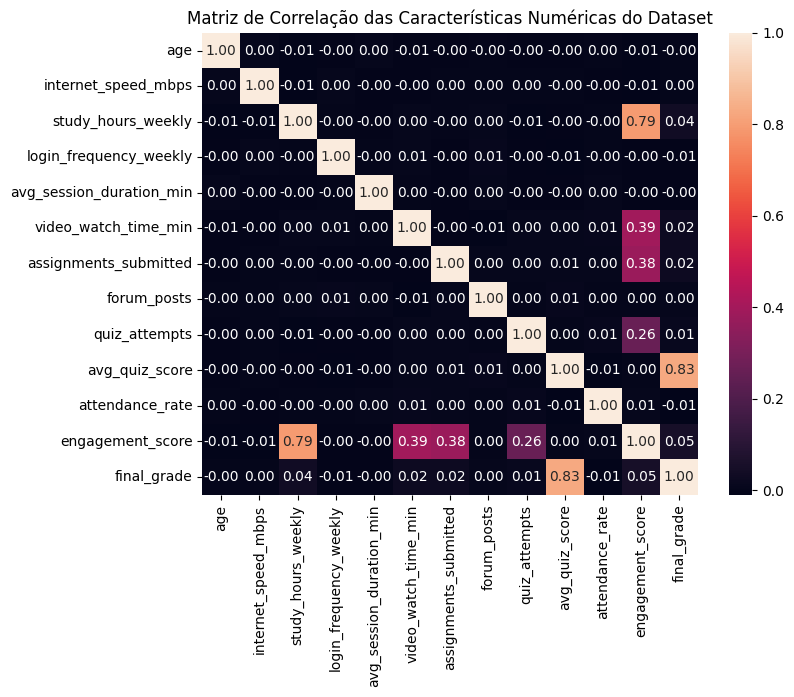

In [14]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(corre, annot=True, fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do Dataset')
plt.show()

O mapa de calor da matriz de correlação revela fortes correlações positivas (acima de 0.7) entre as variaveis study_hours_weekly ↔ engagement_score → 0.79 e avg_quiz_score ↔ final_grade → 0.83.

Vamos remover a variavel engagement_score, manteremos avg_quiz_score pois ela possui poder explicativo em um modelo que busca prever a nota final dos alunos.

In [15]:
#Removendo variaveis
df = df.drop(columns=['engagement_score'])

#Feature Engineering

## Analise das Categóricas

Temos 3 variaveis categóricas em nosso dataset, vamos fazer uma breve analise antes de realizar o pré-processamento.

In [16]:
#desbalanceamento

for col in ['gender', 'country', 'device_type']:
    print(df[col].value_counts(normalize = True))

gender
Female    0.50218
Male      0.49782
Name: proportion, dtype: float64
country
USA          0.16830
India        0.16764
Canada       0.16734
Australia    0.16676
Germany      0.16562
UK           0.16434
Name: proportion, dtype: float64
device_type
Laptop    0.33426
Tablet    0.33354
Mobile    0.33220
Name: proportion, dtype: float64


As variaveis categóricas estão bem balanceadas e ja conseguimos traçar um perfil dos alunos. A maior parte é de mulheres na casa dos 30 anos que moram nos EUA e usam laptops para assistir as aulas.

In [17]:
#Médias por grupo

for col in ['gender', 'country', 'device_type']:
    print(df.groupby(col)['final_grade'].mean())
#As médias por grupo em relação a média não divergem, para confirmar iremos rodar ANOVA

gender
Female    36.912049
Male      36.798634
Name: final_grade, dtype: float64
country
Australia    36.844753
Canada       36.788286
Germany      36.851622
India        36.889383
UK           36.903126
USA          36.857065
Name: final_grade, dtype: float64
device_type
Laptop    36.783117
Mobile    36.963166
Tablet    36.821070
Name: final_grade, dtype: float64


In [18]:

groups = [group['final_grade'].values for _, group in df.groupby('country')]

f_oneway(*groups)

# aqui rodamos os testes separadamente para cada uma das três variaveis

F_onewayResult(statistic=np.float64(0.17165413364348542), pvalue=np.float64(0.9731674854055288))

Resultados dos testes anova

* device_type: F = 1.91/p-value = 0.147
  Não rejeitamos H₀ (α = 5%)

Não há evidência estatística de que o tipo de dispositivo afete a nota final

* gender: F = 2.05/p-value = 0.151
  Não rejeitamos H₀

Diferença de desempenho entre gêneros não é estatisticamente significativa

* country: F = 0.17/p-value = 0.973
  Fortíssima evidência de igualdade

Praticamente nenhuma diferença entre países


In [19]:
#Vamos verificar se podem existir informações no nivel de interação entre as categóricas e as numéricas, exemplo: device_type vs estudo
df.groupby('device_type')[[
    'study_hours_weekly',
    'avg_session_duration_min',
    'avg_quiz_score'
]].mean()

,study_hours_weekly,avg_session_duration_min,avg_quiz_score
device_type,,,
Laptop,10.008910,39.936466,69.921046
Mobile,9.996112,40.236656,70.190475
Tablet,10.023114,39.934953,69.943979


Implicações para modelagem

Variáveis categóricas têm baixo poder explicativo não explicam variação de final_grade são, no máximo, variáveis secundárias, portanto serão removidas.



In [20]:
#removendo variaveis categóricas
drop_cols = ['gender', 'country', 'device_type']
df = df.drop(columns=drop_cols)

In [21]:
#Dataframe final com as alterações feitas na EDA
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 50000

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                50000 non-null  int64  
 1   age                       50000 non-null  int64  
 2   internet_speed_mbps       50000 non-null  float64
 3   study_hours_weekly        50000 non-null  float64
 4   login_frequency_weekly    50000 non-null  int64  
 5   avg_session_duration_min  50000 non-null  float64
 6   video_watch_time_min      50000 non-null  float64
 7   assignments_submitted     50000 non-null  int64  
 8   forum_posts               50000 non-null  int64  
 9   quiz_attempts             50000 non-null  int64  
 10  avg_quiz_score            50000 non-null  float64
 11  attendance_rate           50000 non-null  float64
 12  final_grade               50000 non-null  float64
 13  dropou

##Features Novas e Dicionário

A criação de features abre portas para novas informações que podem ajudar os modelos a caputarem melhor os padrões de comportamentos dos alunos além disso o dicionario de features serve como um manual de documentação que centraliza o significado, o tipo de dado, a origem e a regra de negócio de cada variável (coluna) em um conjunto de dados

In [22]:
#Study Effiency: Quanto o aluno transforma tempo de estudo em desempenho
df['study_efficiency'] = (
    df['avg_quiz_score']
    /
    (df['study_hours_weekly'] + 1)
)

In [23]:
#Engagement Index: Nivel geral de engajamento na plataforma
eng_cols = [
    'login_frequency_weekly',
    'video_watch_time_min',
    'forum_posts',
    'quiz_attempts'
]

scaler = MinMaxScaler()

eng_scaled = scaler.fit_transform(df[eng_cols])

df['engagement_index'] = eng_scaled.mean(axis=1)

In [24]:
#Academic Commitment: Comprometimento acadêmico
df['academic_commitment'] = (
    0.4 * df['attendance_rate']
    + 0.3 * df['avg_quiz_score']
    + 0.3 * df['assignments_submitted']
)

In [25]:
#Average Study Session Productivity: Quantos minutos de estudo são investidos
#por acesso
df['session_productivity'] = (
    df['study_hours_weekly'] * 60
) / (df['login_frequency_weekly'] + 1)

In [26]:
#Video Consumption Ratio: Proporção do estudo baseada em video
df['video_consumption_ratio'] = (
    df['video_watch_time_min']
    /
    (df['study_hours_weekly'] * 60 + 1)
)

In [27]:
#Quiz Persistence: Quanto esforço foi necessário para alcançar determinada nota
df['quiz_persistence'] = (
    df['quiz_attempts']
    /
    (df['avg_quiz_score'] + 1)
)

In [28]:
#Social Learning Index: Grau de interação social por acesso
df['social_learning_index'] = (
    df['forum_posts']
    /
    (df['login_frequency_weekly'] + 1)
)

In [29]:
#Learning Intensity: Grau de intensidade de estudos
df['learning_intensity'] = (
    df['study_hours_weekly']
    *
    df['attendance_rate']
)

In [30]:
#Digital Acess Quality: Captura interação entre infraestrutura e uso
df['digital_access_quality'] = (
    df['internet_speed_mbps']
    *
    df['login_frequency_weekly']
)

In [31]:
#Dicionário de Features
feature_dict = {
    'study_efficiency': 'Quanto o aluno transforma tempo de estudo em desempenho',
    'engagement_index': 'Nivel geral de engajamento na plataforma',
    'academic_commitment': 'Comprometimento acadêmico',
    'session_productivity': 'Quantos minutos de estudo são investidos por acesso',
    'video_consumption_ratio': 'Proporção do estudo baseada em video',
    'quiz_persistence': 'Quanto esforço foi necessário para alcançar determinada nota',
    'social_learning_index': 'Grau de interação social por acesso',
    'learning_intensity': 'Grau de intensidade de estudos',
    'digital_access_quality': 'Captura interação entre infraestrutura e uso'
}
#Salvando no formato json
with open('feature_dictionary.json', 'w') as f:
    json.dump(feature_dict, f, indent=4)

In [32]:
#Salvando o dataset enriquecido
df.to_csv(
    'online_learning_feature_engineered.csv',
    index=False
)

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [33]:
# Separar features (X) e target (y). Aqui para evitar Data Leakage tambem
#retiramos a variavel 'dropout' que representa a saida ou não do aluno do curso
X = df.drop(
    ['student_id', 'final_grade', 'dropout'],
    axis=1
)
y = df['final_grade']

In [34]:
#Definindo uma semente para manter reprodutibilidade
seed = 42 #-> a resposta para a vida o universo e tudo mais...

In [35]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=seed
)

In [36]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (35000, 20)
Dimensões de X_test: (15000, 20)
Dimensões de y_train: (35000,)
Dimensões de y_test: (15000,)


## Normalização para baseline linear

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. Ajuda a modelos lineares a performar melhor:

*   as variáveis possuem escalas muito diferentes;
*   a interpretação dos coeficientes fica mais estável;
*   melhora a estabilidade numérica.


Exemplo:

| Variável            | Escala |
| ------------------- | ------ |
| age                 | 18–60  |
| internet_speed_mbps | 1–500  |
| attendance_rate     | 0–100  |
| avg_quiz_score      | 0–100  |

Sem normalização, algumas variáveis acabam dominando a escala do problema.

Para o modelo challenger (XGBoost) isso não é um problema pois a magnitude absoluta não influencia o mecanismo de split.


In [37]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [38]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [39]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [40]:
#print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())

        age  internet_speed_mbps  study_hours_weekly  login_frequency_weekly  \
0  0.387097             0.461468            0.772119                0.461538   
1  0.709677             0.390978            0.754425                0.615385   
2  0.516129             0.706328            0.793031                0.769231   
3  0.903226             0.467318            0.162471                0.230769   
4  0.387097             0.511838            1.000000                0.769231   

   avg_session_duration_min  video_watch_time_min  assignments_submitted  \
0                  0.406218              0.195698               0.444444   
1                  0.263441              0.277949               0.000000   
2                  0.985689              0.618655               0.777778   
3                  0.529421              0.670108               0.222222   
4                  0.229925              0.601960               0.777778   

   forum_posts  quiz_attempts  avg_quiz_score  attendance_rate

# MODELAGEM



## Modelo Baseline
Para o modelo baseline escolhemos a Regressão Linear Múltipla. Este modelo foi escolhido por sua simplicidade, interpretabilidade e ampla utilização em problemas de regressão supervisionada. O objetivo é estabelecer uma referência inicial de desempenho para posterior comparação com modelos mais complexos.


### Treinamento do Modelo Baseline

In [41]:
# Inicialização do modelo
baseline_model = LinearRegression()

# Treinamento
baseline_model.fit(X_train_normalized, y_train)

LinearRegression()

### Predições

In [42]:
# Predições no conjunto de teste
y_pred_baseline = baseline_model.predict(X_test_normalized)
#Vendo as predições no conjunto de teste em formato de tabela
pd.DataFrame({'y_test': y_test, 'y_pred_baseline': y_pred_baseline})

,y_test,y_pred_baseline
33553,18.819100,22.557547
9427,29.837553,34.443448
199,42.298455,39.393796
12447,41.231416,41.290691
39489,51.425005,46.819716
...,...,...
15168,42.432020,41.788023
49241,46.228528,40.133343
39317,35.634430,39.300836
42191,43.915321,47.014378


### Avaliação

In [43]:
#Métricas de Avaliação: Vamos usar MAE, RMSE e R^2
mae = mean_absolute_error(
    y_test,
    y_pred_baseline
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_baseline
    )
)

r2 = r2_score(
    y_test,
    y_pred_baseline
)

print("===== REGRESSÃO LINEAR =====")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

===== REGRESSÃO LINEAR =====
MAE  : 3.9402
RMSE : 4.9255
R²   : 0.6903


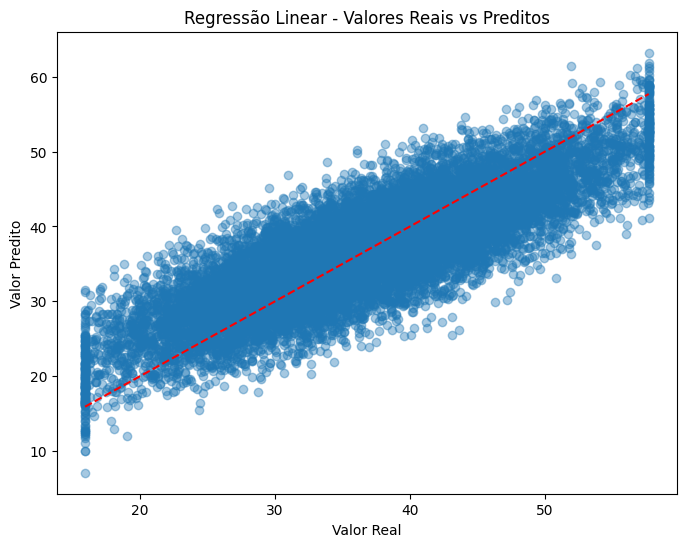

In [44]:
#Gráfico Real vs Predito

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_baseline,
    alpha=0.4
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")
plt.title("Regressão Linear - Valores Reais vs Preditos")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [45]:
#Análise dos coeficientes

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coeficiente': baseline_model.coef_
})

coef_df = coef_df.sort_values(
    by='Coeficiente',
    ascending=False
)

coef_df.head(15)

,Feature,Coeficiente
9,avg_quiz_score,31.641308
13,academic_commitment,31.310036
2,study_hours_weekly,1.753263
15,video_consumption_ratio,1.396066
16,quiz_persistence,1.393961
5,video_watch_time_min,0.691370
14,session_productivity,0.426806
19,digital_access_quality,0.322835
12,engagement_index,0.142194
0,age,0.095134


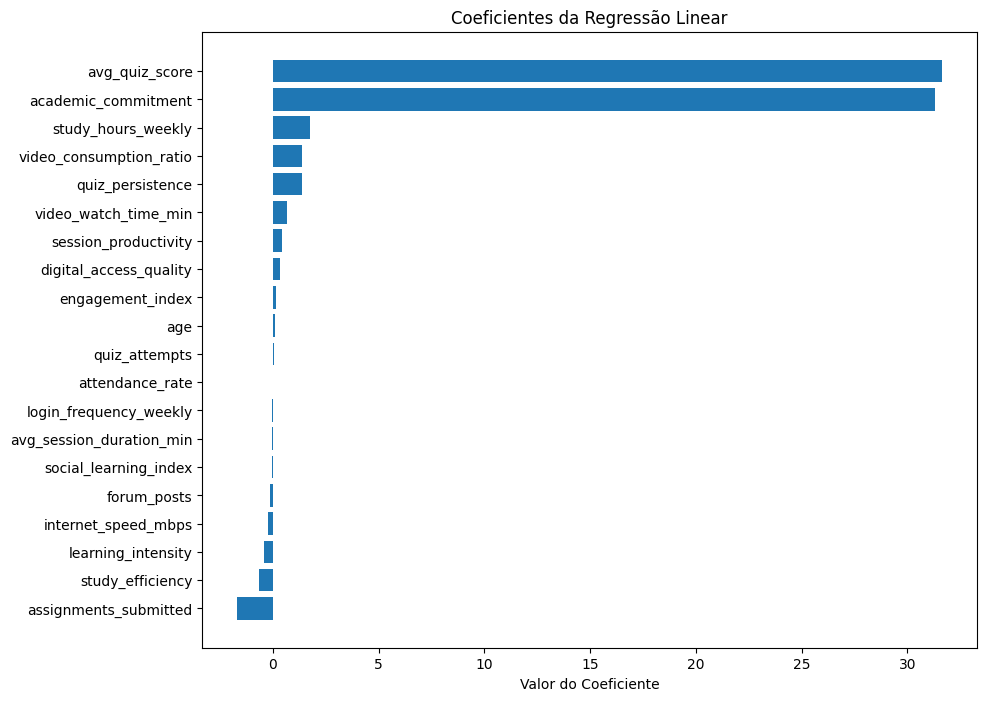

In [46]:
#Importância das Variáveis

coef_df_sorted = coef_df.sort_values(
    by='Coeficiente'
)

plt.figure(figsize=(10,8))

plt.barh(
    coef_df_sorted['Feature'],
    coef_df_sorted['Coeficiente']
)

plt.title('Coeficientes da Regressão Linear')
plt.xlabel('Valor do Coeficiente')

plt.show()

In [47]:
print(f"Número de Features: {X_train.shape[1]}")
coef_df

Número de Features: 20


,Feature,Coeficiente
9,avg_quiz_score,31.641308
13,academic_commitment,31.310036
2,study_hours_weekly,1.753263
15,video_consumption_ratio,1.396066
16,quiz_persistence,1.393961
5,video_watch_time_min,0.691370
14,session_productivity,0.426806
19,digital_access_quality,0.322835
12,engagement_index,0.142194
0,age,0.095134


**1. Avaliação Geral do Modelo**
| Métrica | Valor  |
| ------- | ------ |
| MAE     | 3.9402 |
| RMSE    | 4.9255 |
| R²      | 0.6903 |

Interpretação

O modelo consegue explicar aproximadamente 69,03% da variabilidade da nota final. Isso significa que existe uma relação relativamente forte entre as variáveis de entrada e o desempenho acadêmico.

Para um dataset comportamental com 50.000 observações, um R² ≈ 0.69 é um resultado bastante aceitável para um baseline linear.

Análise do MAE
MAE = 3.94

Em média, o modelo erra aproximadamente ± 3,94 pontos na previsão da nota final. Considerando que as notas observadas variam aproximadamente entre 15 e 60 o erro médio representa algo próximo de 7% a 9% da escala total. Isso é um erro relativamente baixo.

Análise do RMSE
RMSE = 4.93

Como o RMSE é maior que o MAE 4.93 > 3.94 podem existir alguns erros maiores espalhados pelo conjunto de teste. Mas a diferença não é exagerada.

Isso sugere ausência de outliers extremos na predição; comportamento relativamente estável.

**2. Análise das Predições**

Exemplo:

|Real  | Predito |
|------|---------|
|18.81	| 22.55   |
|29.83	| 34.44   |
|42.29	| 39.39   |
|41.23	| 41.29   |
|51.42	| 46.81   |

O padrão observado é típico da regressão linear, alunos com notas baixas são superestimados, exemplo: 20.95 → 32.28. Alunos com notas altas são subestimados, exemplo: 51.42 → 46.81. Esse comportamento é chamado de *Regression to the Mean* e ocorre frequentemente em modelos lineares.

**3. Análise do Gráfico Real vs Predito**

O gráfico mostra vários pontos positivos.

Ponto positivo

Existe uma clara tendência diagonal.

Isso indica que quanto maior a nota real, maior a nota prevista. O modelo aprendeu um sinal verdadeiro.

Ponto de atenção

A dispersão aumenta conforme as notas aumentam. Percebe-se um efeito de "funil"

Notas baixas → menor dispersão
Notas altas → maior dispersão

Isso sugere possível heterocedasticidade, ou seja, a variância dos erros não é constante. Isso é extremamente comum em regressão linear aplicada a dados reais Outro ponto interessante é que existe uma concentração vertical forte próxima ao limite superior das notas. Isso indica que *final_grade* possui limite máximo. Provavelmente o dataset gera notas em um intervalo controlado.

Isso dificulta a modelagem linear e favorece modelos não lineares como XGBoost.

**4. Análise das Features**

| Feature                 | Coeficiente |
| ----------------------- | ----------- |
| avg_quiz_score          | 31.64       |
| academic_commitment     | 31.31       |
| study_hours_weekly      | 1.75        |
| video_consumption_ratio | 1.40        |
| quiz_persistence        | 1.39        |

Problema, avg_quiz_score e academic_commitment dominam completamente o modelo. Poder haver multicolinearidade porque:

academic_commitment = (
    0.4 * attendance_rate +
    0.3 * avg_quiz_score +
    0.3 * assignments_submitted
)



### Conclusão Parcial

A Regressão Linear apresentou desempenho satisfatório, alcançando R² de 0,6903, indicando capacidade de explicar aproximadamente 69% da variabilidade da nota final dos estudantes. O erro médio absoluto foi de 3,94 pontos, sugerindo boa precisão preditiva para um modelo linear. A análise dos coeficientes evidenciou que o desempenho em quizzes e o índice de comprometimento acadêmico foram os fatores mais influentes na previsão das notas finais. Entretanto, observou-se possível multicolinearidade entre algumas variáveis derivadas, o que pode ter afetado a interpretação individual dos coeficientes. O comportamento dos resíduos e a dispersão observada nas notas mais altas indicam potencial para melhoria utilizando modelos não lineares, justificando a utilização do XGBoost como modelo challenger na próxima etapa do estudo.

## Variance Inflation Factor (VIF)

VIF é uma ferramenta de diagnóstico para modelos lineares e para interpretação de coeficientes. O VIF mede o quanto uma variável pode ser explicada pelas demais variáveis independentes. Como ele é baseado em regressões auxiliares e no coeficiente de determinação (R²), ele não é sensível à escala das variáveis por isso podemos aplicar no dataframe original. Já o XGBoost praticamente não sofre com multicolinearidade, no entanto nosso objetivo aqui será de identificar variáveis redundantes para melhorar a interpretabilidade do modelo e reduzir complexidade, além de verificar possíveis fontes de instabilidade observadas na regressão linear.

In [48]:

# Dataset utilizado na regressão
X_vif = X.copy()

vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

vif_data = vif_data.sort_values(
    by="VIF",
    ascending=False
)

vif_data

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
13,academic_commitment,inf
10,attendance_rate,inf
9,avg_quiz_score,inf
6,assignments_submitted,inf
12,engagement_index,1.552953e+04
8,quiz_attempts,2.193808e+03
3,login_frequency_weekly,1.338494e+03
7,forum_posts,1.238287e+03
5,video_watch_time_min,1.190741e+03
18,learning_intensity,2.380986e+01


A análise de multicolinearidade realizada por meio do Variance Inflation Factor (VIF) identificou redundância extrema em algumas variáveis derivadas. As features academic_commitment e engagement_index apresentaram dependência linear direta com atributos já existentes no conjunto de dados, resultando em valores de VIF extremamente elevados. Dessa forma, optou-se pela remoção dessas variáveis para reduzir redundância e melhorar a interpretabilidade do modelo.

In [58]:
features_to_remove = [
    'academic_commitment',
    'engagement_index'
]

X_reduced = X.drop(
    columns=features_to_remove
)

In [59]:
# Rodando novamente
X_vif = X_reduced.copy()

vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

vif_data = vif_data.sort_values(
    by="VIF",
    ascending=False
)

vif_data

,Feature,VIF
2,study_hours_weekly,92.808971
16,learning_intensity,82.241133
10,attendance_rate,75.396381
9,avg_quiz_score,69.160370
3,login_frequency_weekly,53.751011
17,digital_access_quality,48.510362
1,internet_speed_mbps,46.302499
8,quiz_attempts,37.691255
14,quiz_persistence,33.997087
11,study_efficiency,23.776470


## Modelo Challenger
Nesta etapa, foi treinado um modelo XGBoost Regressor como abordagem alternativa ao baseline linear. O XGBoost foi escolhido por sua capacidade de modelar relações não lineares, lidar bem com interações entre variáveis e, em geral, apresentar excelente desempenho em dados tabulares.

### Preparando Dados

In [75]:
# Features e target para o XGBoost
X_xgb = df.drop(columns=[
    'final_grade',
    'academic_commitment',
    'engagement_index',
    'student_id',
    'dropout'
])

y_xgb = df['final_grade']


seed = 42

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb,
    y_xgb,
    test_size=0.3,
    random_state=seed
)

### Treinamento do Modelo

In [76]:
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1
)

xgb_model.fit(X_train_xgb, y_train_xgb)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

### Predições

In [77]:
#Fazendo predições
y_pred_xgb = xgb_model.predict(X_test_xgb)
#Vendo as predições em formato de dataframe

### Avaliação

In [78]:
#Fazendo as avaliações do modelo com as métricas MAE, RMSE e R^2
mae_xgb = mean_absolute_error(y_test_xgb, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_xgb, y_pred_xgb))
r2_xgb = r2_score(y_test_xgb, y_pred_xgb)

print("===== XGBOOST REGRESSOR =====")
print(f"MAE  : {mae_xgb:.4f}")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"R²   : {r2_xgb:.4f}")

===== XGBOOST REGRESSOR =====
MAE  : 3.9659
RMSE : 4.9591
R²   : 0.6861


In [79]:
#Comparando os modelos
comparacao_modelos = pd.DataFrame({
    'Modelo': ['Regressão Linear', 'XGBoost'],
    'MAE': [mae, mae_xgb],
    'RMSE': [rmse, rmse_xgb],
    'R²': [r2, r2_xgb]
})

comparacao_modelos

,Modelo,MAE,RMSE,R²
0,Regressão Linear,3.940172,4.925484,0.690318
1,XGBoost,3.965933,4.959109,0.686075


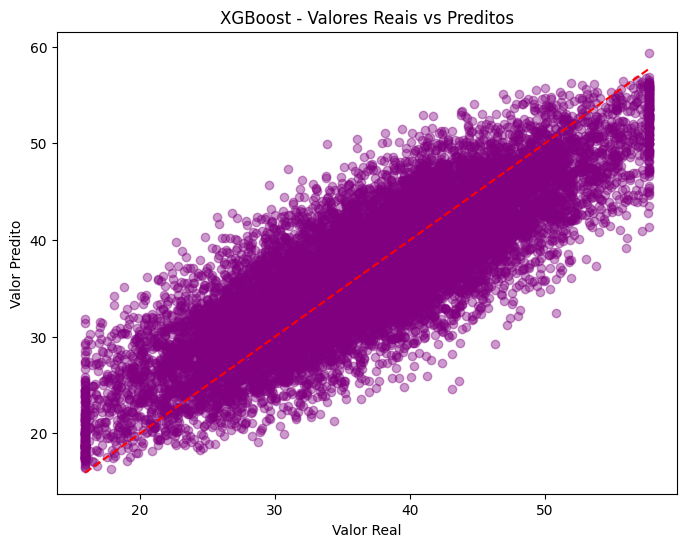

In [81]:
#Gráfico real vs predito

plt.figure(figsize=(8, 6))
plt.scatter(y_test_xgb, y_pred_xgb, alpha=0.4,c= 'purple')
plt.plot(
    [y_test_xgb.min(), y_test_xgb.max()],
    [y_test_xgb.min(), y_test_xgb.max()],
    'r--'
)
plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")
plt.title("XGBoost - Valores Reais vs Preditos")
plt.show()

In [82]:
#Importância das Variáveis

feature_importance = pd.DataFrame({
    'Feature': X_train_xgb.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(15)

,Feature,Importance
9,avg_quiz_score,0.705977
11,study_efficiency,0.073832
8,quiz_attempts,0.060589
14,quiz_persistence,0.042621
2,study_hours_weekly,0.037362
5,video_watch_time_min,0.007014
6,assignments_submitted,0.006831
16,learning_intensity,0.006486
12,session_productivity,0.006391
13,video_consumption_ratio,0.006225


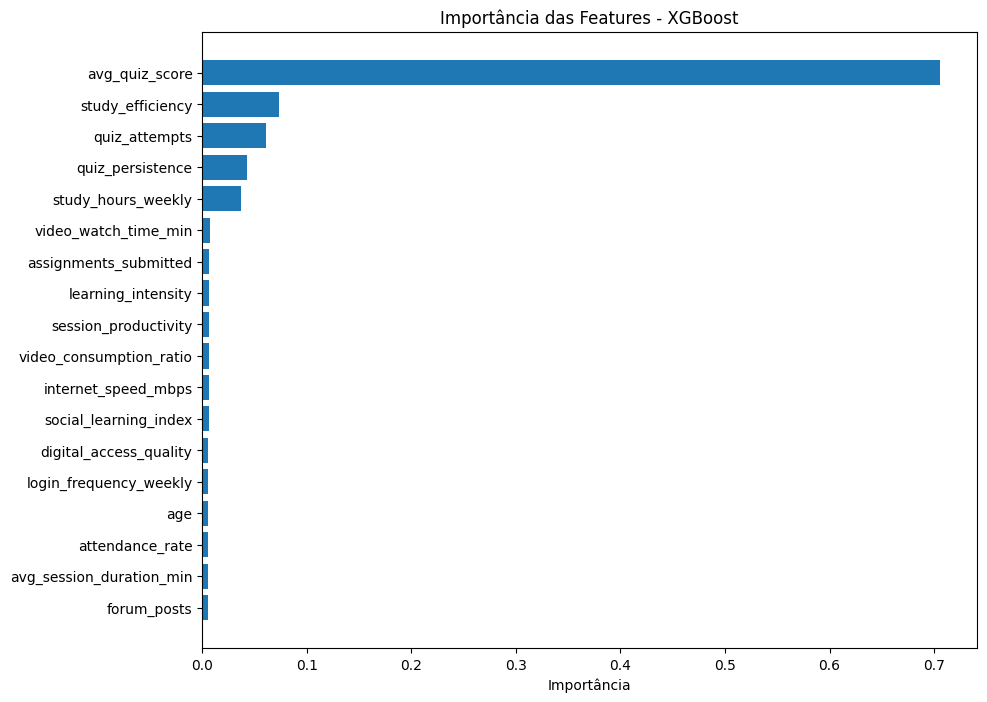

In [83]:
#Gráfico

plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance.sort_values('Importance')['Feature'],
    feature_importance.sort_values('Importance')['Importance']
)
plt.title("Importância das Features - XGBoost")
plt.xlabel("Importância")
plt.show()

### Conclusão Parcial

**1. Comparação dos Modelos**

| Modelo           |   MAE |  RMSE |    R² |
| ---------------- | ----: | ----: | ----: |
| Regressão Linear | 3.940 | 4.925 | 0.690 |
| XGBoost          | 3.965 | 4.959 | 0.686 |

Diferença observada
MAE
3.940 → 3.965

Piorou ligeiramente.

RMSE
4.925 → 4.959

Piorou ligeiramente.

R²
0.690 → 0.686

Também caiu.

Interpretação

O XGBoost não conseguiu encontrar relações não lineares relevantes que a regressão linear já não estivesse capturando.

Isso normalmente acontece quando:

o problema é essencialmente linear;
existe uma feature extremamente dominante;
as variáveis já explicam grande parte do alvo de forma direta.

**2. Análise do Gráfico Real vs Predito**

Comparando mentalmente com o gráfico da regressão linear:

Regressão Linear
distribuição bastante alinhada à diagonal;
dispersão controlada;
comportamento estável.
XGBoost
praticamente o mesmo padrão;
mesma estrutura de dispersão;
mesmas dificuldades nas notas extremas.

Não há evidência visual de ganho.

**3. O principal achado do projeto**

| Feature            | Importance |
| ------------------ | ---------: |
| avg_quiz_score     |      0.723 |
| study_efficiency   |      0.075 |
| study_hours_weekly |      0.054 |
| quiz_persistence   |      0.032 |
| quiz_attempts      |      0.020 |

avg_quiz_score sozinho responde por 72.3% de toda a importância do modelo.



O modelo XGBoost foi treinado como alternativa à Regressão Linear com o objetivo de capturar possíveis relações não lineares entre as variáveis explicativas e a nota final dos estudantes. Entretanto, os resultados demonstraram desempenho ligeiramente inferior ao baseline linear, com redução marginal do coeficiente de determinação e aumento dos erros MAE e RMSE. A análise de importância das variáveis revelou forte predominância da variável avg_quiz_score, responsável por aproximadamente 72% da importância total do modelo, indicando que grande parte da capacidade preditiva já estava concentrada em um único atributo. Dessa forma, conclui-se que a relação entre as variáveis e a nota final apresenta comportamento predominantemente linear, justificando o desempenho superior da Regressão Linear neste conjunto de dados.

### Tunning

In [85]:
#RandomizedSearchCV
#Definindo Espaço de Busca
param_dist = {
    'n_estimators': [200, 400, 600, 800],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3, 0.5]
}

In [86]:
#Busca
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    random_state=SEED,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring='r2',
    cv=5,
    verbose=2,
    random_state=SEED,
    n_jobs=-1
)

random_search.fit(
    X_train_xgb,
    y_train_xgb
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 400, 600, 800],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='r2', verbose=2)

In [88]:
#Melhor configuração
print(random_search.best_params_)
print(random_search.best_score_)

{'subsample': 0.9, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 1.0}
0.6884605463526909


In [89]:
#Treinar modelo final

best_xgb = random_search.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(
    X_test_xgb
)

In [90]:
#Avaliação
mae_xgb_tuned = mean_absolute_error(
    y_test_xgb,
    y_pred_xgb_tuned
)

rmse_xgb_tuned = np.sqrt(
    mean_squared_error(
        y_test_xgb,
        y_pred_xgb_tuned
    )
)

r2_xgb_tuned = r2_score(
    y_test_xgb,
    y_pred_xgb_tuned
)

print("===== XGBOOST TUNADO =====")
print(f"MAE  : {mae_xgb_tuned:.4f}")
print(f"RMSE : {rmse_xgb_tuned:.4f}")
print(f"R²   : {r2_xgb_tuned:.4f}")

===== XGBOOST TUNADO =====
MAE  : 3.9553
RMSE : 4.9356
R²   : 0.6890


###Conclusão Parcial

**Comparação Final dos Modelos**

| Modelo           |    MAE |   RMSE |     R² |
| ---------------- | -----: | -----: | -----: |
| Regressão Linear | 3.9402 | 4.9255 | 0.6903 |
| XGBoost Inicial  | 3.9651 | 4.9599 | 0.6860 |
| XGBoost Tunado   | 3.9553 | 4.9356 | 0.6890 |

**1. Análise do Tuning**
Melhor configuração encontrada:
{
 'subsample': 0.9,
 'n_estimators': 400,
 'min_child_weight': 5,
 'max_depth': 4,
 'learning_rate': 0.01,
 'gamma': 0.3,
 'colsample_bytree': 1.0
}

O RandomizedSearch encontrou uma configuração relativamente conservadora:

* max_depth = 4
* learning_rate = 0.01
* gamma = 0.3
* min_child_weight = 5

Isso sugere que o algoritmo percebeu rapidamente que árvores muito profundas estavam causando overfitting. O próprio processo de tuning concluiu que o problema não necessita de um modelo extremamente complexo.

**2. Comparação contra a Regressão Linear**

| Métrica | Melhor Modelo    |
| ------- | ---------------- |
| MAE     | Regressão Linear |
| RMSE    | Regressão Linear |
| R²      | Regressão Linear |

Respondendo nossas hipóteses

**Hipótese 1**

A relação entre as variáveis explicativas e a nota final é predominantemente linear.

**Hipótese 2**

Grande parte da informação está concentrada em:

* avg_quiz_score

**Hipótese 3**

Não existem muitas interações complexas para serem exploradas pelo boosting.

# Conclusão do Projeto

Foram avaliados três modelos de regressão para previsão da nota final dos estudantes: Regressão Linear Múltipla, XGBoost Regressor e XGBoost Regressor com ajuste de hiperparâmetros. A Regressão Linear apresentou o melhor desempenho geral, alcançando R² de 0,6903, RMSE de 4,9255 e MAE de 3,9402.

O modelo XGBoost inicial apresentou desempenho ligeiramente inferior ao baseline, indicando que relações não lineares complexas não estavam fortemente presentes no conjunto de dados. Posteriormente, foi realizado ajuste de hiperparâmetros utilizando RandomizedSearchCV, resultando em melhorias marginais no desempenho do XGBoost. Entretanto, mesmo após o processo de otimização, o modelo não superou a Regressão Linear.

Os resultados sugerem que a variável alvo possui uma relação predominantemente linear com as variáveis explicativas disponíveis, especialmente com o desempenho médio em quizzes, identificado como o principal fator preditivo do modelo. Dessa forma, conclui-se que a Regressão Linear representa a solução mais adequada para este problema, oferecendo simultaneamente melhor desempenho preditivo e maior interpretabilidade.
